In [63]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset load 

In [64]:
dataset = load_dataset("fancyzhx/ag_news")

df = pd.DataFrame(dataset["train"])

In [65]:
df

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0
119996,Renteria signing a top-shelf deal Red Sox gene...,1
119997,Saban not going to Dolphins yet The Miami Dolp...,1
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1


### Basic Information

In [66]:
df.shape

(120000, 2)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


In [68]:
df.describe()

,label
count,120000.000000
mean,1.500000
std,1.118039
min,0.000000
25%,0.750000
50%,1.500000
75%,2.250000
max,3.000000


### Identifying Text Anomalies 

In [93]:
for text in df["text"]:
    if "http" in text or "www" in text:
        print("URL detected")
        break

URL detected


In [95]:
for text in df["text"]:
    if "  " in text:
        print("Found double spaces")
        break

Found double spaces


In [99]:
for text in df["text"]:
    
    if "@" in text and ".com" in text:
        print("Email detected")
        break

print("No Emails Detected")


No Emails Detected


### Check for Duplicates

In [69]:
df.duplicated().sum()

0

### Missing Values

In [70]:
df.isnull().sum()

text     0
label    0
dtype: int64

### Defining Classes

In [71]:
class_names = dataset["train"].features["label"].names

class_names

['World', 'Sports', 'Business', 'Sci/Tech']

### Class Distribution

In [72]:
class_mapping = dict(enumerate(class_names))
class_mapping

{0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

In [81]:
df["category"] = df["label"].map(class_mapping)

df

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,World
119996,Renteria signing a top-shelf deal Red Sox gene...,1,Sports
119997,Saban not going to Dolphins yet The Miami Dolp...,1,Sports
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,Sports


In [74]:
df['category'].value_counts()

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

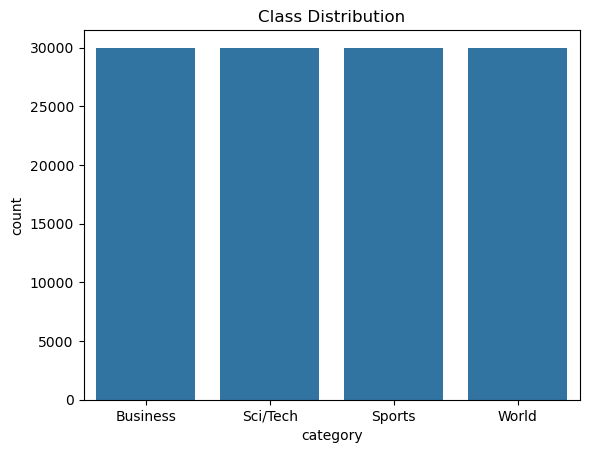

In [75]:
sns.countplot(x = df['category'])
plt.title("Class Distribution")
plt.show()